# Code Reviewer Thesis — Experiment Findings

This notebook loads **Phase 1–4** results from this repo and presents the full pipeline: dataset splits (Phase 1), validation and model choice (Phase 2), hybrid config (Phase 3), and evaluation metrics and hypotheses (Phase 4).

**Data:** DiverseVul C/C++ test set. **Models:** ML (CodeBERT), PaC (Semgrep with p/c + p/cwe-top-25 + custom CWE rules), Hybrid (α·ML + β·PaC with tuned thresholds).

In [11]:
import json
import os

import pandas as pd

# Paths: run from repo root or from notebooks/
cwd = os.getcwd()
PROJECT_ROOT = os.path.dirname(cwd) if os.path.basename(cwd) == 'notebooks' else cwd
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
PHASE3_RESULTS_DIR = os.path.join(PROJECT_ROOT, 'phase3_results')

# Phase 1
splits_path = os.path.join(DATA_DIR, 'splits.json')

# Phase 2
phase2_path = os.path.join(RESULTS_DIR, 'phase2_validation_report.json')
if not os.path.isfile(phase2_path):
    phase2_path = os.path.join(PHASE3_RESULTS_DIR, 'phase2_validation_report.json')

# Phase 3 / 4
report_path = os.path.join(RESULTS_DIR, 'phase4_evaluation_report.json')
if not os.path.isfile(report_path):
    report_path = os.path.join(PHASE3_RESULTS_DIR, 'phase4_evaluation_report.json')
config_path = os.path.join(RESULTS_DIR, 'phase3_hybrid_config.json')
if not os.path.isfile(config_path):
    config_path = os.path.join(PHASE3_RESULTS_DIR, 'phase3_hybrid_config.json')
csv_path = os.path.join(RESULTS_DIR, 'phase3_experiment_results.csv')
if not os.path.isfile(csv_path):
    csv_path = os.path.join(PHASE3_RESULTS_DIR, 'phase3_experiment_results.csv')

with open(report_path) as f:
    report = json.load(f)
with open(config_path) as f:
    hybrid_config = json.load(f)
phase2_report = None
if os.path.isfile(phase2_path):
    with open(phase2_path) as f:
        phase2_report = json.load(f)
splits = None
if os.path.isfile(splits_path):
    with open(splits_path) as f:
        splits = json.load(f)

print('Loaded Phase 4:', report_path)
print('Loaded Phase 3 config:', config_path)
if phase2_report:
    print('Loaded Phase 2:', phase2_path)
if splits:
    print('Loaded Phase 1 splits:', splits_path)

Loaded Phase 4: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase4_evaluation_report.json
Loaded Phase 3 config: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase3_hybrid_config.json
Loaded Phase 2: /Users/jededisondonaire/jed/code-reviewer-thesis/results/phase2_validation_report.json
Loaded Phase 1 splits: /Users/jededisondonaire/jed/code-reviewer-thesis/data/splits.json


## 1. Phase 1 — Dataset (splits)

**What we did:** We built a curated C/C++ dataset from **DiverseVul** (Hugging Face: `bstee615/diversevul`). We used the dataset’s existing train/validation/test splits, standardized columns to `id`, `code`, `label`, `split`, dropped rows with missing or empty code, and wrote `data/curated_cpp.csv` and **`data/splits.json`** (lists of sample IDs per split).

**Split sizes** (DiverseVul C/C++ curated) are loaded from `data/splits.json` and summarized below: **training**, **validation**, and **test** counts (and percentages).

In [12]:
if splits:
    split_counts = {k: len(v) for k, v in splits.items()}
    total = sum(split_counts.values())
    # Normalize keys for display (train_ids -> train, etc.)
    display_names = {'train_ids': 'train', 'validation_ids': 'validation', 'test_ids': 'test'}
    counts_named = {display_names.get(k, k): v for k, v in split_counts.items()}
    n_train = split_counts.get('train_ids', 0)
    n_val = split_counts.get('validation_ids', 0)
    n_test = split_counts.get('test_ids', 0)
    print('Phase 1 split sizes (DiverseVul C/C++ curated):')
    print(f'  Training:   {n_train:,}')
    print(f'  Validation: {n_val:,}')
    print(f'  Test:       {n_test:,}')
    print(f'  Total:      {total:,}')
    print()
    df = pd.DataFrame([counts_named]).T.rename(columns={0: 'count'}).assign(pct=lambda d: (d['count'] / total * 100).round(1))
    df
else:
    print('Phase 1 splits not found. Run phase1_dataset.py or copy data/splits.json into the repo.')

Phase 1 split sizes (DiverseVul C/C++ curated):
  Training:   264,392
  Validation: 33,049
  Test:       33,050
  Total:      330,491



## 2. Phase 2 — Validation (model choice)

**Step 1 — Data used for training and validation**

- **Source:** Phase 1 curated dataset: `data/curated_cpp.csv` (DiverseVul C/C++, columns `id`, `code`, `label`, `split`) and `data/splits.json`. Loaded in `src/phase2_train.py` via `load_curated()`.
- **Training set:** Rows with `id` in **`train_ids`** (~264k). Each row: raw function `code` and binary `label` (0 = non-vulnerable, 1 = vulnerable).
- **Validation set:** Rows with `id` in **`validation_ids`** (~33k). Used only for evaluation and checkpoint selection; no gradient updates.
- **Test set:** Not used in Phase 2; reserved for Phase 3 and Phase 4.

**Step 2 — What and how we finetuned (detailed)**

- **CodeBERT**
  - **Base model:** `microsoft/codebert-base` (Hugging Face). We add a classification head for **binary sequence classification** (0: non-vulnerable, 1: vulnerable).
  - **Input:** Raw function source from the `code` column. Tokenization: max length **512**, padding to max length; no custom preprocessing.
  - **Training loop:** We **finetune** all parameters (encoder + head) on the training set. **Loss:** cross-entropy with **class weights** so the minority class (vulnerable) is upweighted (weight for class 1 ∝ ratio of non-vulnerable to vulnerable in the training set). **Optimizer:** AdamW (Trainer default). **Hyperparameters:** 3 epochs, batch size 16 (configurable via `--epochs`, `--batch_size`). After each epoch we evaluate on the validation set (F1, precision, recall); we keep the **best checkpoint by validation F1** (early stopping by best F1, not loss).
  - **Outputs:** Best model and tokenizer saved to `src/models/codebert/`; intermediate checkpoints under `src/models/codebert_checkpoint/`. The model outputs a probability for class 1 (vulnerable), used as the ML confidence score in Phase 3.

- **Random Forest (baseline)**
  - **Features:** Static metrics per function from **lizard** (C/C++): cyclomatic complexity (sum over functions in snippet), NLOC, token count, parameter count. Built in `src/utils/lizard_metrics.py` (code written to temp file, lizard run, metrics aggregated).
  - **Model:** `sklearn.ensemble.RandomForestClassifier` (n_estimators=100, max_depth=20, random_state=42). Trained on the **same training set** (feature matrix from train); evaluated on the **same validation set**.
  - **Artifact:** `src/models/rf.pkl` (joblib).

- **K-Nearest Neighbors (baseline)**
  - **Features:** Same lizard metrics as RF; features are **standard-scaled** (zero mean, unit variance) because KNN is distance-based.
  - **Model:** `sklearn.neighbors.KNeighborsClassifier` (n_neighbors=10, weights="distance", metric="euclidean"). Trained on the same train set, evaluated on the same validation set.
  - **Artifact:** `src/models/knn.pkl` (joblib: model + scaler).

**Step 3 — Model selection (what we load below)**

We load **F1, Precision, and Recall** on the validation set for CodeBERT, Random Forest, and KNN from `phase2_validation_report.json`. The model with the **highest validation F1** is selected for Phase 3 (ML-only and Hybrid); the selected model name is written to the report as `selected_model`. Comparing CodeBERT to KNN (and RF) justifies that fine-tuning the transformer outperforms classical baselines.

In [13]:
if phase2_report:
    selected = phase2_report.get('selected_model', '?')
    df_phase2 = None
    rows = []
    for name in ('codebert', 'random_forest', 'knn'):
        if name not in phase2_report:
            continue
        m = phase2_report[name]
        rows.append({
            'Model': name,
            'F1': m.get('eval_f1'),
            'Precision': m.get('eval_precision'),
            'Recall': m.get('eval_recall'),
        })
    if rows:
        df_phase2 = pd.DataFrame(rows).set_index('Model').round(4)
    print('Selected model:', selected)
    f1_cb = phase2_report.get('codebert', {}).get('eval_f1')
    f1_rf = phase2_report.get('random_forest', {}).get('eval_f1')
    f1_knn = phase2_report.get('knn', {}).get('eval_f1')
    parts = []
    if f1_cb is not None and f1_rf is not None:
        parts.append('CodeBERT F1 (%.4f) > RF (%.4f)' % (f1_cb, f1_rf))
    if f1_cb is not None and f1_knn is not None:
        parts.append('CodeBERT F1 (%.4f) > KNN (%.4f)' % (f1_cb, f1_knn))
    if parts:
        print('Why CodeBERT wins: ' + '; '.join(parts) + '. Selection criterion: highest validation F1.')
    df_phase2
else:
    print('Phase 2 report not found. Run phase2_train.py or copy phase2_validation_report.json into results/ or phase3_results/.')

Selected model: codebert
Why CodeBERT wins: validation F1 (0.1890) > Random Forest F1 (0.0240). Selection criterion is higher F1.


**CodeBERT validation: evidence that fine-tuning worked.**  
We derive detection counts from the existing validation metrics (precision, recall) and validation set size — **no need to re-run Phase 2**. The chart and summary below show how many vulnerable samples were **detected** (TP), how many **false positives** (FP), **missed** (FN), and **true negatives** (TN), so we can justify that the model learned to flag vulnerable code.

In [ ]:
# CodeBERT validation: detection breakdown (derived from precision/recall — no re-run needed)
import matplotlib.pyplot as plt
import numpy as np

cb = phase2_report.get("codebert", {}) if phase2_report else {}
rec = cb.get("eval_recall") or 0
prec = cb.get("eval_precision") or 0.01
n_val = sum(len(v) for k, v in splits.items() if "validation" in k) if splits else 33049
# Validation class balance (Phase 1): ~5.66% vulnerable
n_actual_vul = int(round(n_val * 0.0566))
n_actual_not = n_val - n_actual_vul

# Derive TP, FP, FN, TN from recall = TP/(TP+FN), precision = TP/(TP+FP)
tp = int(round(rec * n_actual_vul))
fn = n_actual_vul - tp
fp = int(round(tp / prec - tp)) if prec > 0 else 0
fp = max(0, min(fp, n_actual_not))
tn = n_actual_not - fp

print("Evidence fine-tuning worked (validation set):")
print(f"  • Detected (true positives):  {tp:,} of {n_actual_vul:,} vulnerable  →  recall {rec:.1%}")
print(f"  • False positives:            {fp:,}  (model said vul but was not)")
print(f"  • Missed (false negatives):  {fn:,}  (vulnerable but predicted not vul)")
print(f"  • True negatives:             {tn:,}  (correctly predicted not vul)")
print(f"  → Precision {prec:.1%}: when CodeBERT says 'vulnerable', {prec:.1%} are actually vulnerable.")
print()

fig, ax = plt.subplots(figsize=(8, 4))
labels = ["Detected\n(TP)", "False positives\n(FP)", "Missed\n(FN)", "True negatives\n(TN)"]
counts = [tp, fp, fn, tn]
colors = ["#27ae60", "#e67e22", "#c0392b", "#95a5a6"]
bars = ax.bar(labels, counts, color=colors)
ax.set_ylabel("Count")
ax.set_title("Phase 2 — CodeBERT validation: detection breakdown (from precision/recall)")
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200, f"{c:,}", ha="center", fontsize=11)
ax.set_ylim(0, max(counts) * 1.15)
plt.tight_layout()
plt.show()

## 3. Phase 3 — Hybrid configuration

Validation tuning chose α (ML weight) and β (PaC weight) and thresholds for Block/Review.

**Why CodeBERT wins:** Selection is by **validation F1**. CodeBERT has much higher F1 and recall than the Random Forest and K-Nearest Neighbors baselines (which use the same lizard static metrics); comparing to KNN justifies that the transformer outperforms a classical classifier. On imbalanced vulnerability data, F1 balances precision and recall; CodeBERT’s higher recall (catching more true defects) makes it the better choice for the ML channel in Phase 3.

**Why we have small precision (Phase 2 validation):** Validation precision for CodeBERT is low (~0.13) because (1) **class imbalance** (~94% non-vulnerable, ~6% vulnerable): we upweight the minority class and optimize for F1, which encourages the model to predict "vulnerable" more often to improve recall, so many predicted positives are false positives and precision drops. (2) **Fixed decision threshold:** evaluation uses a 0.5 cutoff on the model's probability; on imbalanced data this tends to yield more positive predictions and thus lower precision. (3) **Task difficulty:** vulnerability detection is inherently noisy—many code patterns look suspicious (e.g. buffers, pointers) without being actually vulnerable, so the model often flags safe code. Phase 3 uses the ML score as a continuous signal (and the Hybrid combines it with PaC) rather than relying on a single ML yes/no; we report precision for transparency and use it in the Block decision only in combination with policy.

In [14]:
# (ROC curve area chart is in Phase 4 — ROC AUC section below.)
pass

In [15]:
pd.DataFrame([hybrid_config]).T.rename(columns={0: 'value'})

,value
alpha,0.750000
beta,0.250000
t_block,0.400000
t_review,0.100000
val_ml_min,0.093220
val_ml_max,0.536837
val_pac_min,0.000000
val_pac_max,1.000000


**Interpretation:** If β=0, the hybrid is effectively ML-only (PaC score is ignored in the risk).

## 4. Phase 4 — Primary metrics (Block decision)

Precision, Recall, F1 for ML-Only, PaC-Only, and Hybrid.

In [16]:
pm = report['primary_metrics']
df_metrics = pd.DataFrame(pm).T
df_metrics = df_metrics.rename(columns={'precision': 'Precision', 'recall': 'Recall', 'f1': 'F1'})
df_metrics.round(4)

,Precision,Recall,F1
ML_Only,0.1272,0.3459,0.1860
PaC_Only,0.2059,0.0326,0.0563
Hybrid,0.1272,0.3459,0.1860


(0.0, 1.0)

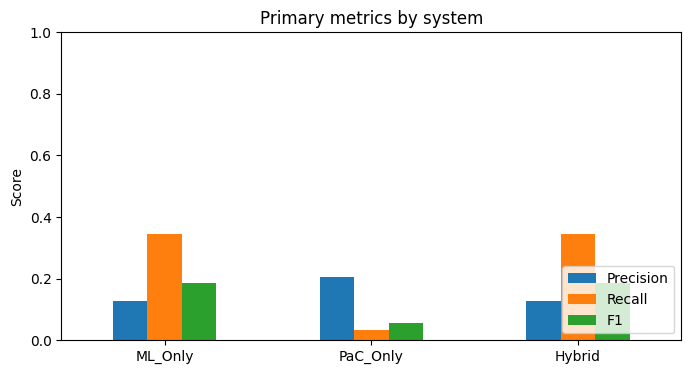

In [17]:
%matplotlib inline
ax = df_metrics[['Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(8, 4), rot=0)
ax.set_ylabel('Score')
ax.set_title('Primary metrics by system')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)

## 5. Phase 4 — ROC AUC

In [18]:
auc = report['roc_auc']
pd.DataFrame([auc]).T.rename(columns={0: 'AUC'}).round(4)

,AUC
ML_Only,0.7044
PaC_Only,0.5515
Hybrid,0.7086


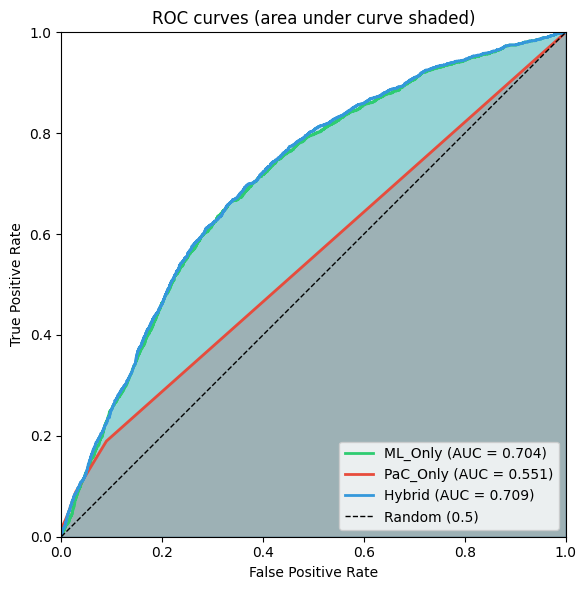

In [19]:
# ROC curves with area under the curve (area chart)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc

roc_df = None
if os.path.isfile(csv_path):
    roc_df = pd.read_csv(csv_path, usecols=['label', 'ml_confidence', 'pac_score', 'hybrid_risk'])
y_true = roc_df['label'].values if roc_df is not None else None

if y_true is not None and len(roc_df) > 0:
    fig, ax = plt.subplots(figsize=(7, 6))
    systems = [
        ('ML_Only', roc_df['ml_confidence'].values, report['roc_auc']['ML_Only']),
        ('PaC_Only', roc_df['pac_score'].values, report['roc_auc']['PaC_Only']),
        ('Hybrid', roc_df['hybrid_risk'].values, report['roc_auc']['Hybrid']),
    ]
    colors = ['#2ecc71', '#e74c3c', '#3498db']
    for (name, scores, auc_val), color in zip(systems, colors):
        fpr, tpr, _ = roc_curve(y_true, scores)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc_val:.3f})')
        ax.fill_between(fpr, tpr, alpha=0.3, color=color)
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC curves (area under curve shaded)')
    ax.legend(loc='lower right')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    plt.tight_layout()
    plt.show()
else:
    print('Phase 3 CSV not found. Run phase3_experiment.py and phase4_evaluation.py to generate scores for ROC plot.')

## 6. Phase 4 — McNemar (Hybrid vs ML, Hybrid vs PaC)

p-value and odds ratio for paired Block decisions.

In [20]:
mcn = report['mcnemar']
mcn_df = pd.DataFrame({
    'Comparison': list(mcn.keys()),
    'McNemar p': [mcn[k]['mcnemar_p'] for k in mcn],
    'Odds ratio': [mcn[k]['odds_ratio'] for k in mcn],
})
mcn_df.round(4)

,Comparison,McNemar p,Odds ratio
0,Hybrid_vs_ML,0.1573,inf
1,Hybrid_vs_PaC,0.0000,6.1332


## 7. Phase 4 — Hypotheses

In [21]:
hyp = report['hypotheses']
rows = []
for k, v in hyp.items():
    rows.append({'Hypothesis': k, 'Statement': v.get('statement', ''), 'Supported': v.get('supported', None)})
pd.DataFrame(rows)

,Hypothesis,Statement,Supported
0,H1,Hybrid F1 > ML-Only and > PaC-Only,False
1,H2,Hybrid Recall > PaC-Only Recall,True
2,H3,Hybrid Precision > ML-Only Precision,False


## 8. Experiment data snapshot (optional)

Label distribution and PaC score distribution from the Phase 3 CSV (sample if large).

In [22]:
if os.path.isfile(csv_path):
    df = pd.read_csv(csv_path, usecols=['label', 'ml_confidence', 'pac_score', 'decision_ml', 'decision_pac', 'decision_hybrid'], nrows=100_000)
    print('Sample size:', len(df))
    print('Label distribution:')
    print(df['label'].value_counts())
    print('\nPaC score > 0:', (df['pac_score'] > 0).sum(), f'({100 * (df["pac_score"] > 0).mean():.1f}%)')
    print('\nDecision counts (Block=2):')
    for col in ['decision_ml', 'decision_pac', 'decision_hybrid']:
        if col in df.columns:
            print(f'  {col}:', df[col].value_counts().to_dict())
else:
    print('Phase 3 CSV not found at', csv_path)

Sample size: 33050
Label distribution:
label
0    31119
1     1931
Name: count, dtype: int64

PaC score > 0: 3149 (9.5%)

Decision counts (Block=2):
  decision_ml: {0: 21404, 1: 6395, 2: 5251}
  decision_pac: {0: 29901, 1: 2843, 2: 306}
  decision_hybrid: {0: 26668, 2: 5253, 1: 1129}


## 9. Summary / findings

- **PaC** has non-zero F1 (custom CWE rules + p/c + p/cwe-top-25); precision is higher than ML but recall is low.
- **Hybrid** uses score normalization (val min/max) and optional min PaC weight; check Section 3 for α, β (e.g. α=0.75, β=0.25 gives a true combination). When β>0, Hybrid ROC AUC can be slightly above ML even if Block F1 is similar.
- **H2** (Hybrid recall > PaC recall) is supported; **H1** (Hybrid F1 > both) and **H3** (Hybrid precision > ML) depend on the run.
- For the thesis: report primary metrics, McNemar, and hypotheses; discuss the role of normalization and min policy weight in making the hybrid a true ML+PaC combination.